# Multi Arm Bandit

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Configuración de la "máquina" (simulador)
def crear_maquina_poisson(lambdas):
    def simular(brazo_idx):
        # brazo_idx viene de 0 a n-1 en Python
        return np.random.poisson(lambdas[brazo_idx])
    
    simular.n_brazos = len(lambdas)
    return simular

# Instanciamos la simulación con distintos pesos (1, 8, 10)
simular = crear_maquina_poisson([1, 8, 10])

In [4]:
simular(2)

11

In [5]:
# Generar 3000 muestras aleatorias de brazos (1, 2, 3)
n_muestras = 3000
brazos = np.random.choice([0, 1, 2], size=n_muestras)

# Simular las recompensas usando la función que definimos antes
# Aplicamos la función 'simular' a cada brazo elegido
recompensas = [simular(b) for b in brazos]

# Guardamos la simulaciones
sim_recomp = pd.DataFrame({
    'brazo': brazos + 1,
    'recompensa': recompensas
})

sim_recomp['media'] = sim_recomp.groupby('brazo')['recompensa'].transform('mean')

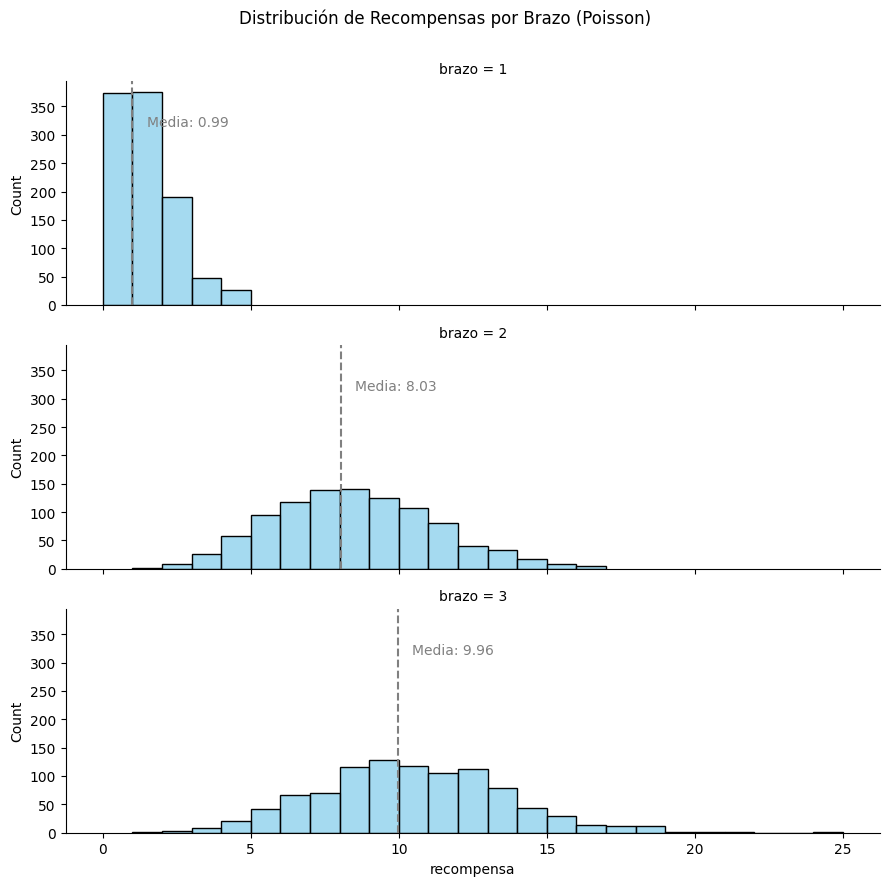

In [6]:
# Crear la cuadrícula de gráficas (una columna, filas según el brazo)
g = sns.FacetGrid(sim_recomp, row="brazo", height=3, aspect=3, sharex=True)

# Añadir el histograma
g.map(sns.histplot, "recompensa", binwidth=1, kde=False, color="skyblue")

# Añadir la línea vertical de la media para cada brazo
def annotate_mean(data, **kwargs):
    m = data['recompensa'].mean()
    plt.axvline(m, color='gray', linestyle='--')
    plt.text(m + 0.5, plt.ylim()[1]*0.8, f'Media: {m:.2f}', color='gray')

g.map_dataframe(annotate_mean)

plt.subplots_adjust(top=0.9)
g.fig.suptitle('Distribución de Recompensas por Brazo (Poisson)')
plt.show()

## Algoritmo Epsilon Miope

In [7]:
class EpsilonMiope:
    def __init__(self, epsilon, sim_fun, inicial=0):
        self.epsilon = epsilon
        self.sim_fun = sim_fun
        self.n_brazos = sim_fun.n_brazos
        
        self.conteos = np.zeros(self.n_brazos)
        self.sumas = np.zeros(self.n_brazos)
        self.S = np.zeros(self.n_brazos) # Para el error estándar
        self.mejor_brazo = inicial
        self.iteracion = 0

    def dar_paso(self):
        # Decide Explorar o Explotar
        if np.random.rand() < self.epsilon:
            brazo = np.random.choice(self.n_brazos)
        else:
            brazo = self.mejor_brazo

        # Ejecutar simulación
        recompensa = self.sim_fun(brazo)

        # Actualizar estadísticas
        self.iteracion += 1
        media_anterior = self.sumas[brazo] / self.conteos[brazo] if self.conteos[brazo] > 0 else 0

        self.conteos[brazo] += 1
        self.sumas[brazo] += recompensa
        media_actual = self.sumas[brazo] / self.conteos[brazo]

        # Cálculo de varianza online (fórmula de Welford simplificada para S)
        self.S[brazo] += (recompensa - media_anterior) * (recompensa - media_actual)

        # Actualizar quién es el mejor hasta ahora
        medias = np.divide(
            self.sumas,
            self.conteos,
            out=np.zeros_like(self.sumas),
            where=self.conteos!=0
            )
        self.mejor_brazo = np.argmax(medias)

        # Retornar el estado actual como un DataFrame de una fila por brazo
        ee = np.sqrt(
            np.divide(self.S, self.conteos, out=np.zeros_like(self.S), where=self.conteos!=0)) / \
            np.sqrt(np.maximum(self.conteos, 1))

        estado = pd.DataFrame({
            'n': [self.iteracion] * self.n_brazos,
            'brazo': np.arange(1, self.n_brazos + 1),
            'conteo': self.conteos,
            'suma': self.sumas,
            'media': medias,
            'error_estandar': ee
        })
        return estado

In [8]:
np.random.seed(9233)
agente = EpsilonMiope(epsilon=0.3, sim_fun=simular)

# Correr 600 iteraciones y concatenar resultados
lista_estados = [agente.dar_paso() for _ in range(600)]
df_iteraciones = pd.concat(lista_estados).reset_index(drop=True)

df_iteraciones.head(30)

,n,brazo,conteo,suma,media,error_estandar
0,1,1,1.0,1.0,1.000000,0.000000
1,1,2,0.0,0.0,0.000000,0.000000
2,1,3,0.0,0.0,0.000000,0.000000
3,2,1,2.0,4.0,2.000000,0.707107
4,2,2,0.0,0.0,0.000000,0.000000
5,2,3,0.0,0.0,0.000000,0.000000
6,3,1,3.0,6.0,2.000000,0.471405
7,3,2,0.0,0.0,0.000000,0.000000
8,3,3,0.0,0.0,0.000000,0.000000
9,4,1,4.0,7.0,1.750000,0.414578


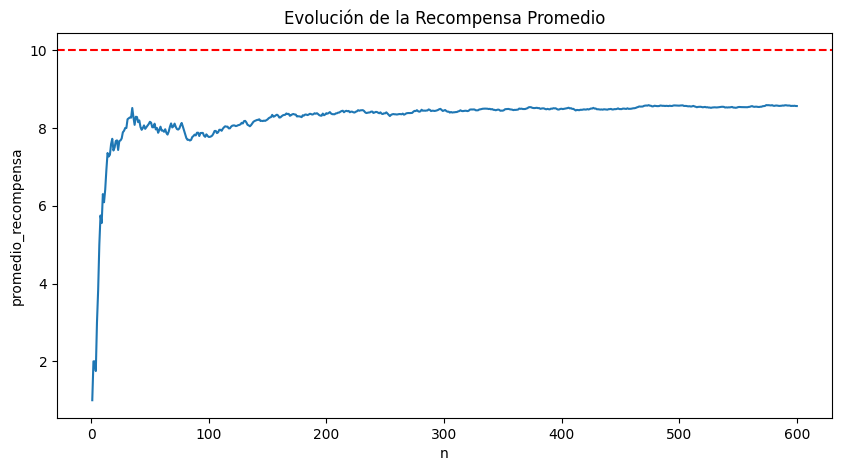

In [9]:
resumen = df_iteraciones.groupby('n').apply(
    lambda x: x['suma'].sum() / x['conteo'].sum()
    ).reset_index(name='promedio_recompensa')

plt.figure(figsize=(10, 5))
sns.lineplot(data=resumen, x='n', y='promedio_recompensa')
plt.axhline(y=10, color='red', linestyle='--', label='Óptimo (Brazo 3)')
plt.title("Evolución de la Recompensa Promedio")
plt.show()

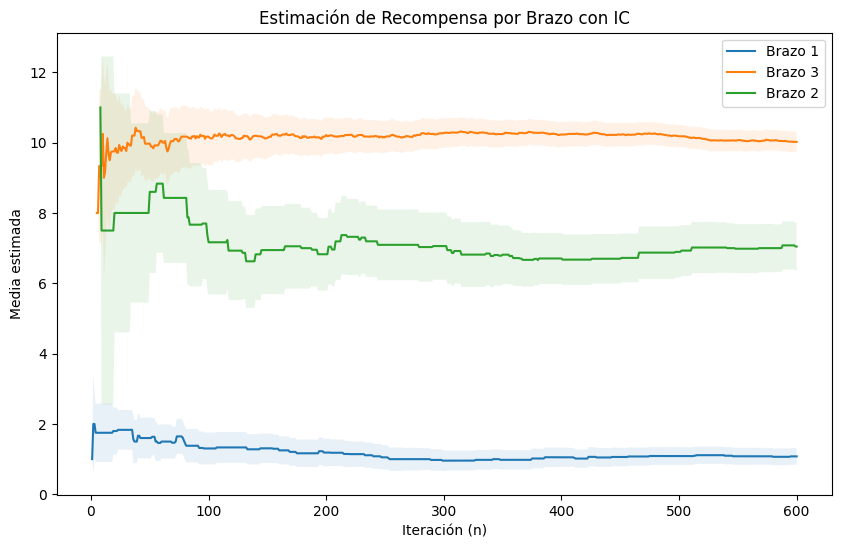

In [10]:
plt.figure(figsize=(10, 6))
# Filtrar donde ya hubo al menos un conteo para evitar saltos en la gráfica
df_plot = df_iteraciones[df_iteraciones['conteo'] > 0].copy()

for brazo in df_plot['brazo'].unique():
    data_brazo = df_plot[df_plot['brazo'] == brazo]
    plt.plot(data_brazo['n'], data_brazo['media'], label=f'Brazo {brazo}')

    # Intervalo de 2 errores estándar (Ribbon)
    plt.fill_between(data_brazo['n'], 
                     data_brazo['media'] - 2*data_brazo['error_estandar'], 
                     data_brazo['media'] + 2*data_brazo['error_estandar'], 
                     alpha=0.1)

plt.legend()
plt.xlabel("Iteración (n)")
plt.ylabel("Media estimada")
plt.title("Estimación de Recompensa por Brazo con IC")
plt.show()

In [11]:
def estrategia_aleatoria(sim_fun, pasos=600):
    recompensas = []
    total_acumulado = 0
    n_brazos = sim_fun.n_brazos
    
    for _ in range(pasos):
        brazo = np.random.choice(n_brazos)
        recompensa = sim_fun(brazo)
        total_acumulado += recompensa
        recompensas.append(total_acumulado)
        
    return recompensas

In [12]:
# Configuración
np.random.seed(42)
pasos = 600
epsilon = 0.3

# --- Correr Epsilon-Miope ---
agente_miope = EpsilonMiope(epsilon=epsilon, sim_fun=simular)
recomp_acum_miope = []
suma_actual_miope = 0

for _ in range(pasos):
    estado = agente_miope.dar_paso()
    # Obtenemos la última recompensa sumando las diferencias en 'suma'
    # o más fácil, registrándola en el loop:
    # (Para este ejemplo, recalculamos el total de la columna 'suma')
    suma_actual_miope = estado['suma'].sum()
    recomp_acum_miope.append(suma_actual_miope)

# --- Correr Aleatorio ---
recomp_acum_azar = estrategia_aleatoria(simular, pasos=pasos)

# --- Crear DataFrame para graficar ---
df_comparacion = pd.DataFrame({
    'Iteracion': np.arange(1, pasos + 1),
    'Epsilon-Miope (0.3)': recomp_acum_miope,
    'Azar (Random)': recomp_acum_azar,
    'Optimo Teórico (Media 10)': np.arange(1, pasos + 1) * 10
})

<>:4: SyntaxWarning: invalid escape sequence '\e'
<>:4: SyntaxWarning: invalid escape sequence '\e'
/var/folders/xp/09_m9yj956x3kbv7qgpqgd6r0000gn/T/ipykernel_17982/2940462588.py:4: SyntaxWarning: invalid escape sequence '\e'
  sns.lineplot(data=df_comparacion, x='Iteracion', y='Epsilon-Miope (0.3)', label='$\epsilon$-Miope (Explora 30%)')


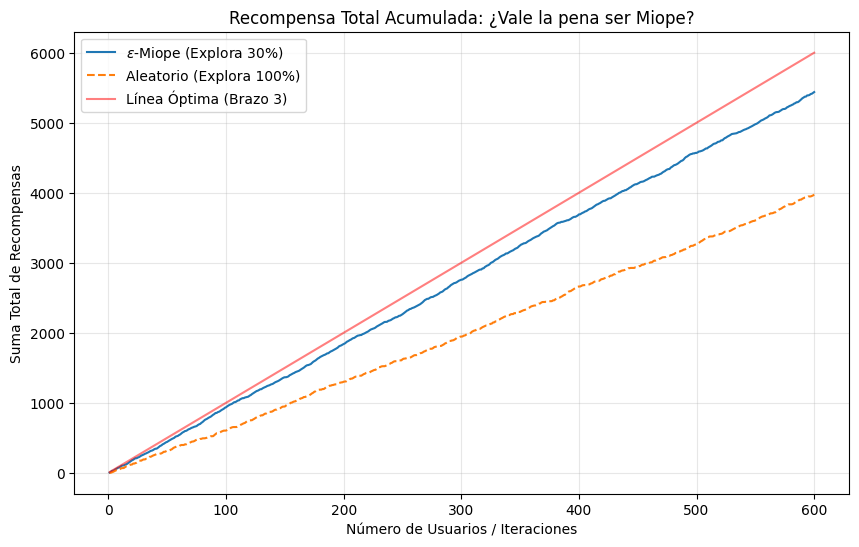

In [13]:
plt.figure(figsize=(10, 6))

# Graficar líneas
sns.lineplot(data=df_comparacion, x='Iteracion', y='Epsilon-Miope (0.3)', label='$\epsilon$-Miope (Explora 30%)')
sns.lineplot(data=df_comparacion, x='Iteracion', y='Azar (Random)', label='Aleatorio (Explora 100%)', linestyle='--')
sns.lineplot(data=df_comparacion, x='Iteracion', y='Optimo Teórico (Media 10)', label='Línea Óptima (Brazo 3)', color='red', alpha=0.5)

plt.title("Recompensa Total Acumulada: ¿Vale la pena ser Miope?")
plt.ylabel("Suma Total de Recompensas")
plt.xlabel("Número de Usuarios / Iteraciones")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()